In [ ]:
%%bash
set -e

# =========================

KAGGLE_TOKEN="Your_own_kaggle_api_token"

# 1) Kaggle 인증 세팅
mkdir -p /root/.kaggle
echo "$KAGGLE_TOKEN" > /root/.kaggle/access_token
chmod 600 /root/.kaggle/access_token

# 2) 데이터 다운로드 + 압축해제
cd /content
kaggle datasets download -d metwalli/linemod-occlusionlinemod-dataset -p /content
mkdir -p /content/linemod_data
unzip -o /content/linemod-occlusionlinemod-dataset.zip -d /content/linemod_data

echo "✅ DOWNLOAD DONE"

Dataset URL: https://www.kaggle.com/datasets/metwalli/linemod-occlusionlinemod-dataset
License(s): apache-2.0

Archive:  /content/linemod-occlusionlinemod-dataset.zip
  inflating: /content/linemod_data/Linemod_preprocessed/annotations/train_annotations.json  
  inflating: /content/linemod_data/Linemod_preprocessed/annotations/validation_annotations.json  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0000.png  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0001.png  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0002.png  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0003.png  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0004.png  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0005.png  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0006.png  
  inflating: /content/linemod_data/Linemod_preprocessed/data/01/depth/0007.

100%|██████████| 8.37G/8.37G [01:45<00:00, 84.9MB/s]


In [ ]:
from pathlib import Path
root = Path("/content/linemod_data")
files = [p for p in root.rglob("*") if p.is_file()]
print("✅ 데이터 폴더 존재:", root.exists())
print("✅ 파일 개수:", len(files))

✅ 데이터 폴더 존재: True
✅ 파일 개수: 72473


이미지 개수: 63218


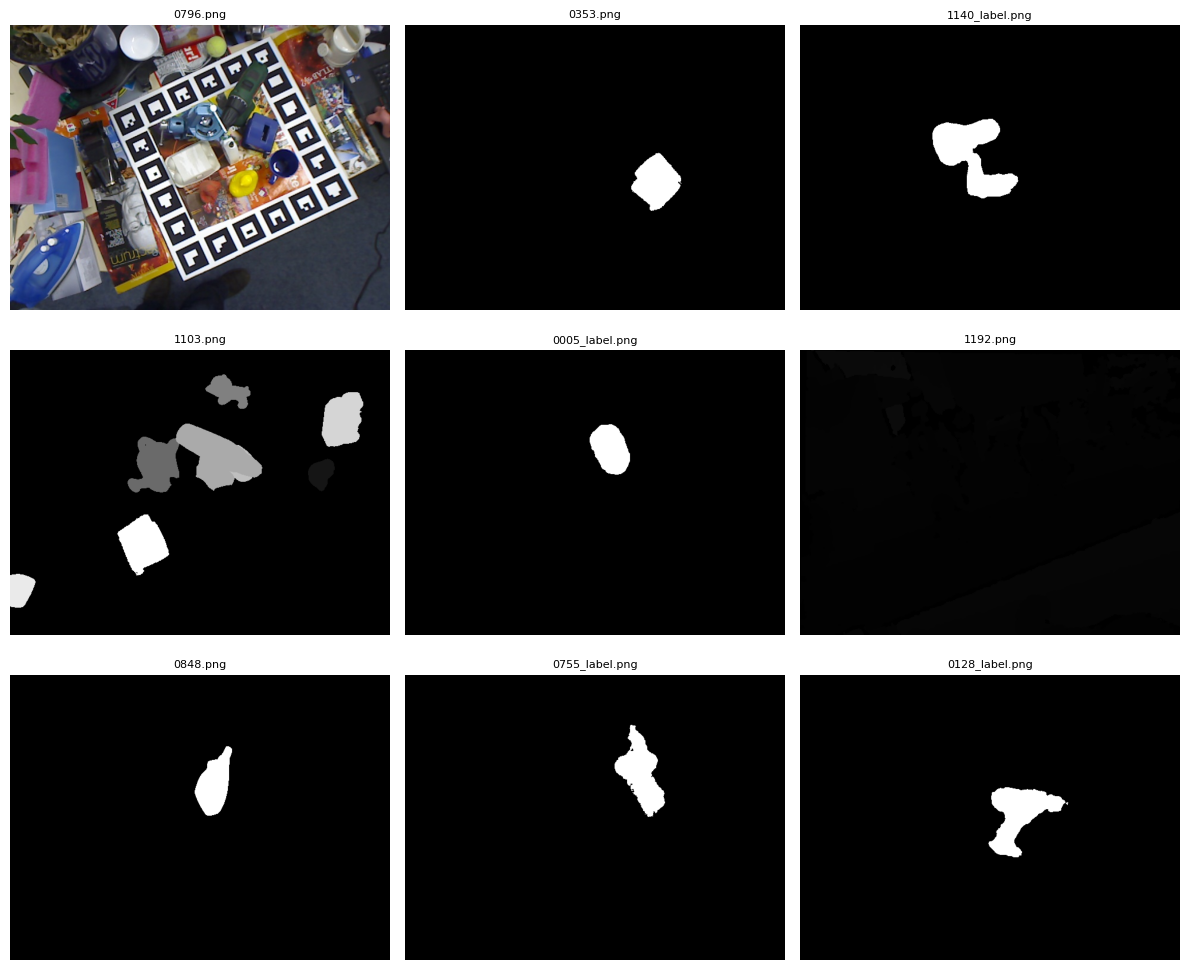

In [ ]:
from pathlib import Path
import random, cv2
import matplotlib.pyplot as plt

root = Path("/content/linemod_data")
imgs = [p for p in root.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]

print("이미지 개수:", len(imgs))
sample = random.sample(imgs, min(9, len(imgs)))

plt.figure(figsize=(12,10))
for i, p in enumerate(sample, 1):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.title(p.name, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import random

root = Path("/content/linemod_data")
img_ext = {".jpg", ".jpeg", ".png"}
img_paths = [p for p in root.rglob("*") if p.suffix.lower() in img_ext]

print("이미지 개수:", len(img_paths))
for p in random.sample(img_paths, min(20, len(img_paths))):
    print(p)

이미지 개수: 63218
/content/linemod_data/Linemod_preprocessed/data/09/mask/0769.png
/content/linemod_data/Linemod_preprocessed/data/02/mask/1151.png
/content/linemod_data/Linemod_preprocessed/data/04/rgb/0300.png
/content/linemod_data/Linemod_preprocessed/data/10/mask/0150.png
/content/linemod_data/Linemod_preprocessed/segnet_results/09_label/0036_label.png
/content/linemod_data/Linemod_preprocessed/segnet_results/08_label/0975_label.png
/content/linemod_data/Linemod_preprocessed/segnet_results/14_label/0991_label.png
/content/linemod_data/Linemod_preprocessed/data/09/rgb/1127.png
/content/linemod_data/Linemod_preprocessed/data/10/rgb/0432.png
/content/linemod_data/Linemod_preprocessed/data/12/mask/1117.png
/content/linemod_data/Linemod_preprocessed/data/06/depth/0260.png
/content/linemod_data/Linemod_preprocessed/data/13/depth/0171.png
/content/linemod_data/Linemod_preprocessed/data/04/rgb/0802.png
/content/linemod_data/Linemod_preprocessed/segnet_results/11_label/0010_label.png
/content/l

RGB 이미지 수: 15800


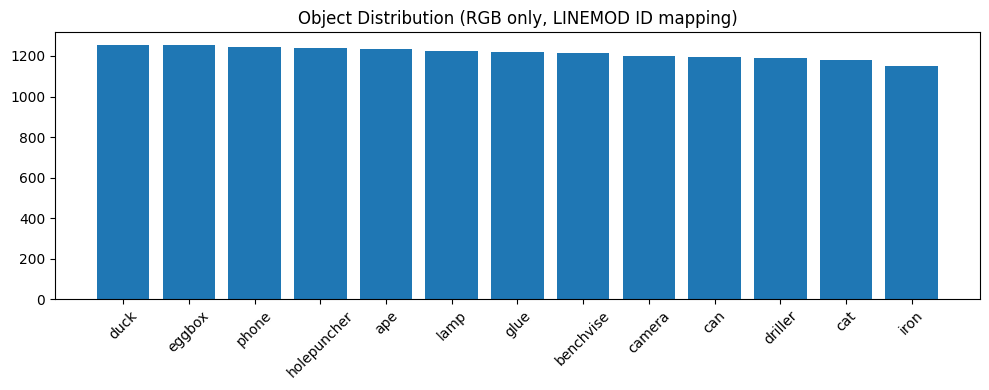

CSV: /content/capstone_outputs/object_distribution_rgb_only.csv
PNG: /content/capstone_outputs/object_distribution_rgb_only.png


,object,count
0,duck,1254
1,eggbox,1253
2,phone,1243
3,holepuncher,1237
4,ape,1236
5,lamp,1227
6,glue,1220
7,benchvise,1214
8,camera,1201
9,can,1196


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

root = Path("/content/linemod_data")

# LINEMOD ID -> object name (표준 매핑)
id_to_obj = {
    "01": "ape",
    "02": "benchvise",
    "04": "camera",
    "05": "can",
    "06": "cat",
    "08": "driller",
    "09": "duck",
    "10": "eggbox",
    "11": "glue",
    "12": "holepuncher",
    "13": "iron",
    "14": "lamp",
    "15": "phone",
}

# 핵심: data/<id>/rgb/*.png 만 대상으로 제한
rgb_paths = []
for p in root.rglob("*.png"):
    s = str(p).replace("\\", "/")
    if "/Linemod_preprocessed/data/" in s and "/rgb/" in s:
        rgb_paths.append(p)

print("RGB 이미지 수:", len(rgb_paths))

rows = []
for p in rgb_paths:
    s = str(p).replace("\\", "/")
    m = re.search(r"/data/(\d{2})/rgb/", s)
    if m:
        oid = m.group(1)
        obj = id_to_obj.get(oid, f"id_{oid}")
    else:
        obj = "unknown"
    rows.append((str(p), obj))

df = pd.DataFrame(rows, columns=["path", "object"])
cnt = df["object"].value_counts().reset_index()
cnt.columns = ["object", "count"]

# 저장
save_dir = Path("/content/capstone_outputs")
save_dir.mkdir(parents=True, exist_ok=True)
csv_path = save_dir / "object_distribution_rgb_only.csv"
png_path = save_dir / "object_distribution_rgb_only.png"
cnt.to_csv(csv_path, index=False)

# 시각화
plt.figure(figsize=(10,4))
plt.bar(cnt["object"], cnt["count"])
plt.title("Object Distribution (RGB only, LINEMOD ID mapping)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(png_path, dpi=150)
plt.show()

print("CSV:", csv_path)
print("PNG:", png_path)
display(cnt)